
REML stands for **Restricted Maximum Likelihood**.

It is a method used to estimate **variance components** in statistical models, especially in **linear mixed models**.

REML is very common in:

- statistical genetics,
- animal breeding,
- GWAS mixed models,
- heritability estimation,
- longitudinal data analysis,
- repeated-measures analysis,
- multi-level modeling.

In statistical genetics, REML appears frequently in methods such as:

- GCTA-GREML,
- genomic relationship matrix models,
- SNP heritability estimation,
- variance component models.

The main purpose of REML is to estimate variance parameters more accurately than ordinary maximum likelihood, especially when fixed effects are present.


## Why Do We Need REML?

In many statistical models, we estimate two types of parameters:

1. fixed effects,
2. variance components.

Fixed effects describe average effects.

For example:

- age effect,
- sex effect,
- SNP effect,
- treatment effect,
- batch effect.

Variance components describe sources of variability.

For example:

- genetic variance,
- residual variance,
- family-level variance,
- individual-level random effects,
- environmental variance.



A mixed model may look like this:

$
y = X\beta + Zu + \epsilon
$

where:

- \( y \) is the phenotype,
- \( $X\beta$ \) represents fixed effects,
- \( Zu \) represents random effects,
- \( $\epsilon$ \) is residual error.

The random effects are usually assumed to follow:

$
u \sim N(0, \sigma_u^2 I)
$

and the residual errors are:

$
\epsilon \sim N(0, \sigma_e^2 I)
$

The goal is often to estimate:

$
\sigma_u^2
$

and:

$
\sigma_e^2
$

These are variance components.

### Maximum Likelihood

Maximum likelihood estimation, often abbreviated as ML, estimates parameters by finding values that make the observed data most likely.

In simple terms, ML asks:

> Given this model, what parameter values make my observed data most probable?

For a linear model:

$
y = X\beta + \epsilon
$

ML estimates both:

- fixed effects,
- variance parameters

using the same likelihood.

However, this creates a problem.


### The Problem with Ordinary Maximum Likelihood

Ordinary maximum likelihood tends to underestimate variance components.

This happens because ML does not fully account for the fact that fixed effects were estimated from the data.

When we estimate fixed effects, we use some information from the data.

That reduces the remaining independent information available for estimating variance.

In simple linear regression, this is why we estimate residual variance using:

$
\frac{RSS}{n-p}
$

instead of:

$
\frac{RSS}{n}
$

where:

- \( n \) is the number of observations,
- \( p \) is the number of estimated fixed-effect parameters.

The term \( n-p \) accounts for the degrees of freedom lost by estimating fixed effects.

REML is based on a similar idea.


### What REML Does

REML estimates variance components after accounting for the fixed effects.

Instead of using the likelihood of the raw data \( y \), REML uses the likelihood of transformed data that no longer depends on the fixed effects.

Conceptually, REML removes the part of the data explained by fixed effects and estimates variance components from the remaining residual variation.

This gives less biased variance estimates.

### REML Meaning

REML is called **Restricted Maximum Likelihood** because the likelihood is constructed from a restricted part of the data.

It is also sometimes called:

- residual maximum likelihood,
- restricted likelihood,
- marginal likelihood of error contrasts.

The key idea is:

> Estimate variance components using only the part of the data that is independent of fixed-effect estimates.


### Simple Example: Variance Estimation

Suppose we have a simple linear regression:

$
y_i = \beta_0 + \epsilon_i
$

Here, the only fixed effect is the intercept.

If we estimate variance using ML:

$
\hat{\sigma}^2_{ML}
=
\frac{1}{n}
\sum_{i=1}^{n}(y_i - \bar{y})^2
$

But the usual unbiased estimate is:

$
\hat{\sigma}^2
=
\frac{1}{n-1}
\sum_{i=1}^{n}(y_i - \bar{y})^2
$

Why \( n-1 \)?

Because one parameter, the mean, was estimated.

REML generalizes this correction to more complex mixed models.

#### ML vs REML

| Feature | ML | REML |
|---|---|---|
| Estimates fixed effects | Yes | Indirectly |
| Estimates variance components | Yes | Yes |
| Accounts for loss of fixed-effect degrees of freedom | No | Yes |
| Variance estimates | Often downward biased | Less biased |
| Good for comparing fixed effects | Yes | No, if fixed effects differ |
| Good for estimating variance components | Less preferred | Preferred |



### Important Practical Rule

Use **ML** when comparing models with different fixed effects.

Use **REML** when comparing models with the same fixed effects but different random effects or when the main goal is estimating variance components.

Why?

Because REML likelihood depends on the fixed-effect design matrix.

Therefore, REML likelihoods are not directly comparable across models with different fixed effects.


### REML in Linear Mixed Models

A linear mixed model can be written as:

$
y = X\beta + Zu + \epsilon
$

where:

$
u \sim N(0, G)
$

and:

$
\epsilon \sim N(0, R)
$

Then:

$
y \sim N(X\beta, V)
$

where:

$
V = ZGZ^T + R
$

The matrix \( V \) is the covariance matrix of the phenotype.

REML estimates the variance components inside \( V \).


### REML in Statistical Genetics

In statistical genetics, REML is especially important because we often want to estimate how much trait variation is explained by genetic similarity.

A common model is:

$
y = X\beta + g + \epsilon
$

where:

$
g \sim N(0, G\sigma_g^2)
$

and:

$
\epsilon \sim N(0, I\sigma_e^2)
$

Here:

- \( G \) is the genetic relationship matrix,
- \( \sigma_g^2 \) is genetic variance,
- \( \sigma_e^2 \) is residual variance.

The total phenotypic variance is:

$
\sigma_p^2 = \sigma_g^2 + \sigma_e^2
$

SNP heritability is estimated as:

$
h^2_{SNP}
=
\frac{\sigma_g^2}
{\sigma_g^2 + \sigma_e^2}
$

REML is used to estimate \( $\sigma_g^2$ \) and \( $\sigma_e^2$ \).


### Intuition for REML Heritability Estimation

The idea is simple:

If genetically similar individuals also have similar phenotypes, then genetic variance is large.

If genetic similarity does not predict phenotype similarity, then genetic variance is small.

REML helps estimate how much phenotype covariance can be explained by the GRM.

### Why REML Is Used in GCTA-GREML

GCTA-GREML uses REML to estimate SNP heritability.

The model is:

$
y = X\beta + g + \epsilon
$

with:

$
g \sim N(0, G\sigma_g^2)
$

REML estimates:

- genetic variance,
- residual variance,
- SNP heritability.

The GRM defines expected genetic covariance between individuals.

REML estimates how strongly this covariance structure explains the observed phenotype.














### REML and the Covariance Matrix

In REML, the covariance matrix is central.

The phenotype covariance matrix is:

$
V = G\sigma_g^2 + I\sigma_e^2
$

where:

- \( $G\sigma_g^2$ \) captures genetic similarity,
- \( $I\sigma_e^2$ \) captures individual-specific residual variation.

REML searches for variance values that make the observed phenotype data most consistent with this covariance structure.

### Step-by-Step Conceptual View

REML works roughly as follows:

1. Start with phenotype data and covariates.
2. Remove variation explained by fixed effects.
3. Use the remaining residual variation.
4. Compare residual phenotype similarity to genetic similarity.
5. Estimate genetic and residual variance components.
6. Compute heritability if needed.

### Example: Simulating a Simple Mixed Model in Python

In this example, we simulate grouped data.

Each group has its own random effect.

This is similar in spirit to genetic models where individuals share some background similarity.





In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Number of groups
n_groups = 20

# Individuals per group
n_per_group = 10

# Total sample size
n = n_groups * n_per_group

# Group IDs
groups = np.repeat(np.arange(n_groups), n_per_group)

# Fixed-effect predictor
x = np.random.normal(0, 1, n)

# True fixed effects
beta_0 = 2.0
beta_1 = 1.5

# True variance components
sigma_group = 1.2
sigma_residual = 1.0

# Random group effects
group_effects = np.random.normal(0, sigma_group, n_groups)

# Outcome
y = beta_0 + beta_1 * x + group_effects[groups] + np.random.normal(0, sigma_residual, n)

# Create dataframe
df = pd.DataFrame({
    "y": y,
    "x": x,
    "group": groups
})

df.head()



,y,x,group
0,5.489075,0.496714,0
1,0.354683,-0.138264,0
2,4.087138,0.647689,0
3,3.101174,1.523030,0
4,1.606183,-0.234153,0


## Fit a Mixed Model Using REML

We can fit a mixed model using `statsmodels`.

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y        
No. Observations: 200     Method:             REML     
No. Groups:       20      Scale:              0.9292   
Min. group size:  10      Log-Likelihood:     -308.6862
Max. group size:  10      Converged:          Yes      
Mean group size:  10.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     2.548    0.328  7.779 0.000  1.906  3.190
x             1.479    0.077 19.269 0.000  1.329  1.629
Group Var     2.052    0.759                           

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y        
No. Observations: 200     Method:             ML       
No. Groups:       20      Scale:              0.9241   
Min. group size:  10      Log-Likelihood:     -306.8262
Max. grou

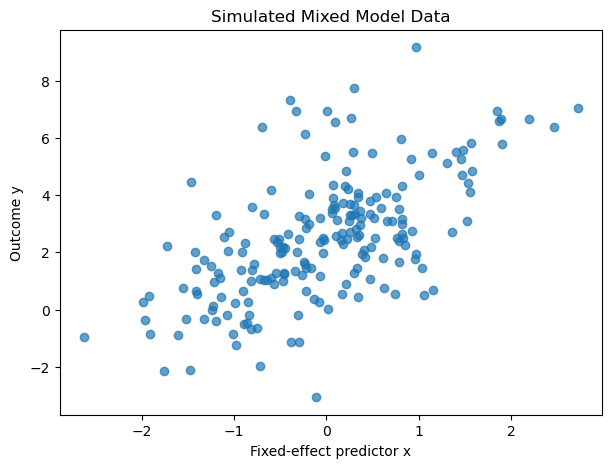

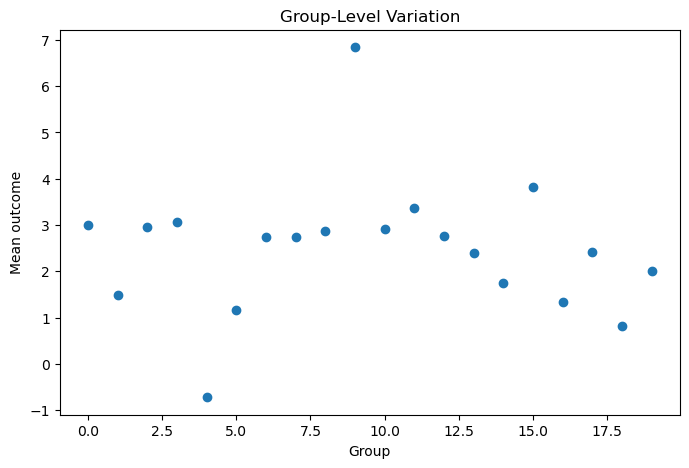

In [2]:
import statsmodels.formula.api as smf

# Fit mixed model using REML
model_reml = smf.mixedlm("y ~ x", data=df, groups=df["group"])
result_reml = model_reml.fit(reml=True)

print(result_reml.summary())


# Fit the Same Model Using ML


# Fit mixed model using ML
model_ml = smf.mixedlm("y ~ x", data=df, groups=df["group"])
result_ml = model_ml.fit(reml=False)

print(result_ml.summary())


# Compare Variance Estimates

comparison = pd.DataFrame({
    "Method": ["REML", "ML"],
    "Group variance": [
        result_reml.cov_re.iloc[0, 0],
        result_ml.cov_re.iloc[0, 0]
    ],
    "Residual variance": [
        result_reml.scale,
        result_ml.scale
    ]
})

comparison


# Visualize the Simulated Data


import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(df["x"], df["y"], alpha=0.7)

plt.xlabel("Fixed-effect predictor x")
plt.ylabel("Outcome y")
plt.title("Simulated Mixed Model Data")

plt.show()


# Visualize Group-Level Means


group_means = df.groupby("group")["y"].mean().reset_index()

plt.figure(figsize=(8,5))

plt.scatter(group_means["group"], group_means["y"])

plt.xlabel("Group")
plt.ylabel("Mean outcome")
plt.title("Group-Level Variation")

plt.show()




### Example: REML-Like Heritability Intuition

Now let us simulate a simple genetic-style example.

We create:

- a genetic relationship matrix,
- a genetic random effect,
- residual noise,
- and a phenotype.

This is a simplified educational example, not a full GCTA implementation.

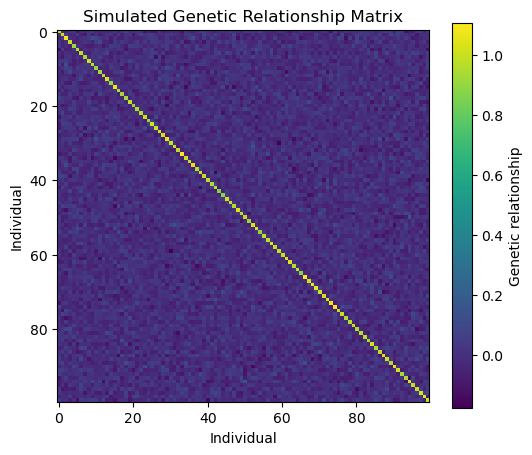

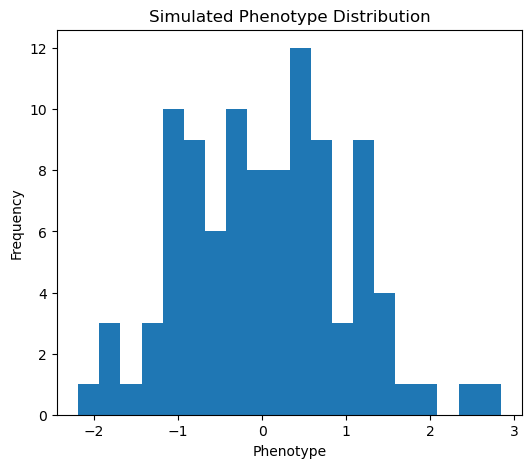

In [3]:

import numpy as np
import pandas as pd

np.random.seed(123)

n = 100
m = 500

# Simulate genotype matrix: 0, 1, 2
genotypes = np.random.binomial(2, 0.3, size=(n, m))

# Estimate allele frequency
p = genotypes.mean(axis=0) / 2

# Standardize genotypes
Z = (genotypes - 2 * p) / np.sqrt(2 * p * (1 - p) + 1e-8)

# Genetic relationship matrix
GRM = (Z @ Z.T) / m

# True variance components
sigma_g2 = 0.6
sigma_e2 = 0.4

# Simulate genetic effect using GRM covariance
genetic_effect = np.random.multivariate_normal(
    mean=np.zeros(n),
    cov=GRM * sigma_g2
)

# Simulate residual effect
residual = np.random.normal(0, np.sqrt(sigma_e2), n)

# Phenotype
phenotype = genetic_effect + residual

# Put into dataframe
pheno_df = pd.DataFrame({
    "individual": [f"ID{i+1}" for i in range(n)],
    "phenotype": phenotype
})

pheno_df.head()


# Visualize the GRM


import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(GRM)

plt.colorbar(label="Genetic relationship")
plt.title("Simulated Genetic Relationship Matrix")

plt.xlabel("Individual")
plt.ylabel("Individual")

plt.show()


# Visualize Phenotype Distribution


plt.figure(figsize=(6,5))

plt.hist(phenotype, bins=20)

plt.xlabel("Phenotype")
plt.ylabel("Frequency")
plt.title("Simulated Phenotype Distribution")

plt.show()




### Heritability in This Simulation

The true SNP heritability in this simulation is:

$
h^2 =
\frac{\sigma_g^2}
{\sigma_g^2 + \sigma_e^2}
$

In [4]:
true_h2 = sigma_g2 / (sigma_g2 + sigma_e2)

true_h2

0.6

In this simulation, we set:

- genetic variance = 0.6,
- residual variance = 0.4.

Therefore:

$
h^2 = 0.6
$

A real REML algorithm would estimate these variance components from the phenotype and GRM.



### REML vs Fixed-Effect Regression

Fixed-effect regression estimates mean effects.

For example:

$
y = X\beta + \epsilon
$

This answers:

> What is the average effect of X on y?

REML in mixed models estimates variance components.

This answers:

> How much variation is explained by a random source such as genetics, family, group, or individual?

This distinction is important.



### When Should You Use REML?

Use REML when:

- estimating variance components,
- estimating heritability,
- fitting mixed models,
- analyzing random effects,
- modeling repeated measurements,
- accounting for relatedness,
- using GRM-based models.

Use ML instead when:

- comparing models with different fixed effects,
- performing likelihood ratio tests for fixed effects,
- selecting among fixed-effect structures.

### Common Misunderstanding

REML does not mean the model has no fixed effects.

A REML model can include fixed effects.

The difference is that REML estimates variance components after accounting for the uncertainty introduced by estimating fixed effects.

### REML in One Sentence

REML estimates variance components from the part of the data that remains after fixed effects are accounted for.



## Summary

REML stands for Restricted Maximum Likelihood.

It is mainly used to estimate variance components in mixed models.

Ordinary ML often underestimates variance components because it does not fully account for fixed effects estimated from the data.

REML corrects this by estimating variance components from residual information independent of fixed effects.

In statistical genetics, REML is central because it allows us to estimate genetic variance and SNP heritability using the Genetic Relationship Matrix.

The core idea behind REML-based heritability estimation is:

> genetically similar individuals should have more similar phenotypes if genetics contributes to the trait.

### References

1. Patterson HD and Thompson R. (1971). Recovery of inter-block information when block sizes are unequal.
2. Henderson CR. (1984). Applications of Linear Models in Animal Breeding.
3. Yang J et al. (2011). GCTA: A Tool for Genome-wide Complex Trait Analysis.
4. Lee SH et al. (2011). Estimating missing heritability for disease from genome-wide association studies.
5. Lynch M and Walsh B. Genetics and Analysis of Quantitative Traits.
6. Visscher PM et al. (2008). Heritability in the genomics era.